In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report
from scipy.sparse import hstack
import streamlit as st


In [2]:
df = pd.read_csv("flipkart.csv")
df

,Unnamed: 0,Product_name,Review,Rating
0,0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5
...,...,...,...,...
2299,2299,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,"Great display, accurate colours at this price ...",5
2300,2300,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Superb monitor first brought 1 used for 2 mont...,5
2301,2301,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Awesome,5
2302,2302,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Only one issue with adapter,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    2304 non-null   int64 
 1   Product_name  2304 non-null   object
 2   Review        2304 non-null   object
 3   Rating        2304 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 72.1+ KB


In [4]:
df.describe()

,Unnamed: 0,Rating
count,2304.000000,2304.000000
mean,1151.500000,4.259549
std,665.251832,1.180017
min,0.000000,1.000000
25%,575.750000,4.000000
50%,1151.500000,5.000000
75%,1727.250000,5.000000
max,2303.000000,5.000000


In [5]:
df.isnull().sum()

Unnamed: 0      0
Product_name    0
Review          0
Rating          0
dtype: int64

In [6]:
df.columns

Index(['Unnamed: 0', 'Product_name', 'Review', 'Rating'], dtype='object')

In [7]:
df.columns.values[0] = "NO."

In [8]:
df.columns

Index(['NO.', 'Product_name', 'Review', 'Rating'], dtype='object')

In [9]:
df.dropna(inplace=True)

In [10]:
df

,NO.,Product_name,Review,Rating
0,0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5
...,...,...,...,...
2299,2299,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,"Great display, accurate colours at this price ...",5
2300,2300,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Superb monitor first brought 1 used for 2 mont...,5
2301,2301,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Awesome,5
2302,2302,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Only one issue with adapter,5


In [11]:
def sentiment(r):
    if r >= 4:
        return "Positive"
    elif r == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Rating'].apply(sentiment)
df

,NO.,Product_name,Review,Rating,Sentiment
0,0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,Positive
1,1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,Positive
2,2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,Positive
3,3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,Positive
4,4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,Positive
...,...,...,...,...,...
2299,2299,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,"Great display, accurate colours at this price ...",5,Positive
2300,2300,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Superb monitor first brought 1 used for 2 mont...,5,Positive
2301,2301,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Awesome,5,Positive
2302,2302,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Only one issue with adapter,5,Positive


In [12]:
le = LabelEncoder()
df['Sentiment'] = le.fit_transform(df['Sentiment'])
df


,NO.,Product_name,Review,Rating,Sentiment
0,0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,2
1,1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,2
2,2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,2
3,3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,2
4,4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,2
...,...,...,...,...,...
2299,2299,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,"Great display, accurate colours at this price ...",5,2
2300,2300,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Superb monitor first brought 1 used for 2 mont...,5,2
2301,2301,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Awesome,5,2
2302,2302,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Only one issue with adapter,5,2


In [13]:
df['Review'] = df['Review'].str.lower()

In [14]:
df['Product_name'] = df['Product_name'].str.lower()
df

,NO.,Product_name,Review,Rating,Sentiment
0,0,lenovo ideapad gaming 3 ryzen 5 hexa core 5600...,best under 60k great performancei got it for a...,5,2
1,1,lenovo ideapad gaming 3 ryzen 5 hexa core 5600...,good perfomence...,5,2
2,2,lenovo ideapad gaming 3 ryzen 5 hexa core 5600...,great performance but usually it has also that...,5,2
3,3,dell inspiron athlon dual core 3050u - (4 gb/2...,my wife is so happy and best product 👌🏻😘,5,2
4,4,dell inspiron athlon dual core 3050u - (4 gb/2...,"light weight laptop with new amazing features,...",5,2
...,...,...,...,...,...
2299,2299,msi 27 inch full hd ips panel monitor (pro mp2...,"great display, accurate colours at this price ...",5,2
2300,2300,msi 27 inch full hd ips panel monitor (pro mp2...,superb monitor first brought 1 used for 2 mont...,5,2
2301,2301,msi 27 inch full hd ips panel monitor (pro mp2...,awesome,5,2
2302,2302,msi 27 inch full hd ips panel monitor (pro mp2...,only one issue with adapter,5,2


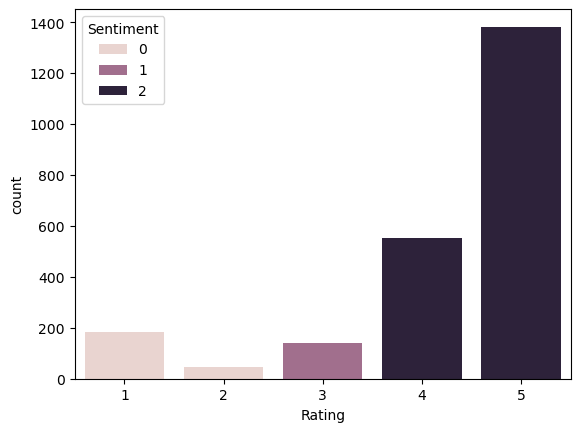

In [15]:
sns.countplot(x='Rating', hue='Sentiment', data=df)
plt.show()

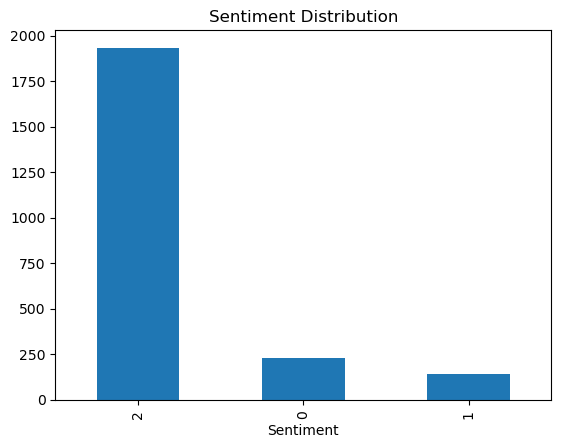

In [16]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

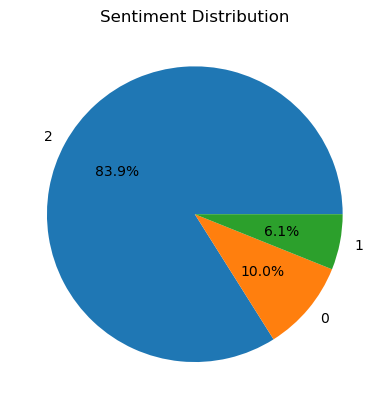

In [17]:
sentiment_counts = df['Sentiment'].value_counts()
plt.figure()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')

plt.title("Sentiment Distribution")
plt.show()

In [18]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['Review'])   
y = df['Sentiment']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

In [20]:
model = LogisticRegression(class_weight='balanced')  
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [21]:
def predict_sentiment_from_product(product_name):
    
    product_name = product_name.lower().strip()
    
    product_reviews = df[
        df['Product_name']
        .str.lower()
        .str.contains(product_name, regex=False)
    ]
    
    if len(product_reviews) == 0:
        words = product_name.split()
        
        for word in words:
            product_reviews = df[
                df['Product_name']
                .str.lower()
                .str.contains(word, regex=False)
            ]
            if len(product_reviews) > 0:
                break
    
    if len(product_reviews) == 0:
        return "Product not found in dataset"
    
    review_text = product_reviews['Review'].iloc[0]
    
    vec = tfidf.transform([review_text])
    pred = model.predict(vec)
    
    return pred[0]

In [22]:
y_pred = model.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
cr = classification_report(y_test, y_pred)
print("Classification Report:\n", cr)

Accuracy: 0.8915401301518439
Confusion Matrix:
 [[ 48   0   5]
 [  0  17  12]
 [  9  24 346]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87        53
           1       0.41      0.59      0.49        29
           2       0.95      0.91      0.93       379

    accuracy                           0.89       461
   macro avg       0.74      0.80      0.76       461
weighted avg       0.91      0.89      0.90       461



In [26]:
product = input("Enter Product Name: ")
result = predict_sentiment_from_product(product)
print("Predicted Sentiment:", result)

Enter Product Name:  samsung galaxy f22 (denim blue, 64 gb)


Predicted Sentiment: 2


In [25]:
df.to_csv("final_flipkart_sentiment.csv", index=False)